In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns

In [3]:
data = pd.read_csv('Maternal Health Risk Data Set.csv')
display(pd.DataFrame(data))

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


In [4]:
data = data.drop_duplicates()

In [5]:
data['RiskLevel'].value_counts()

,count
RiskLevel,
low risk,234
high risk,112
mid risk,106


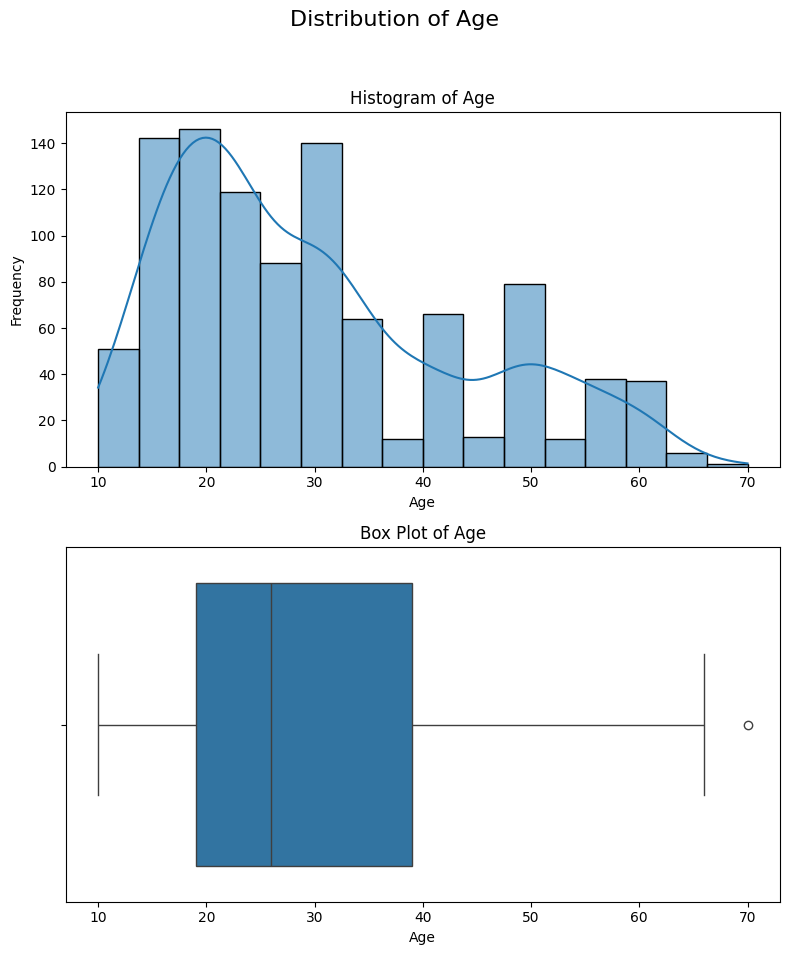

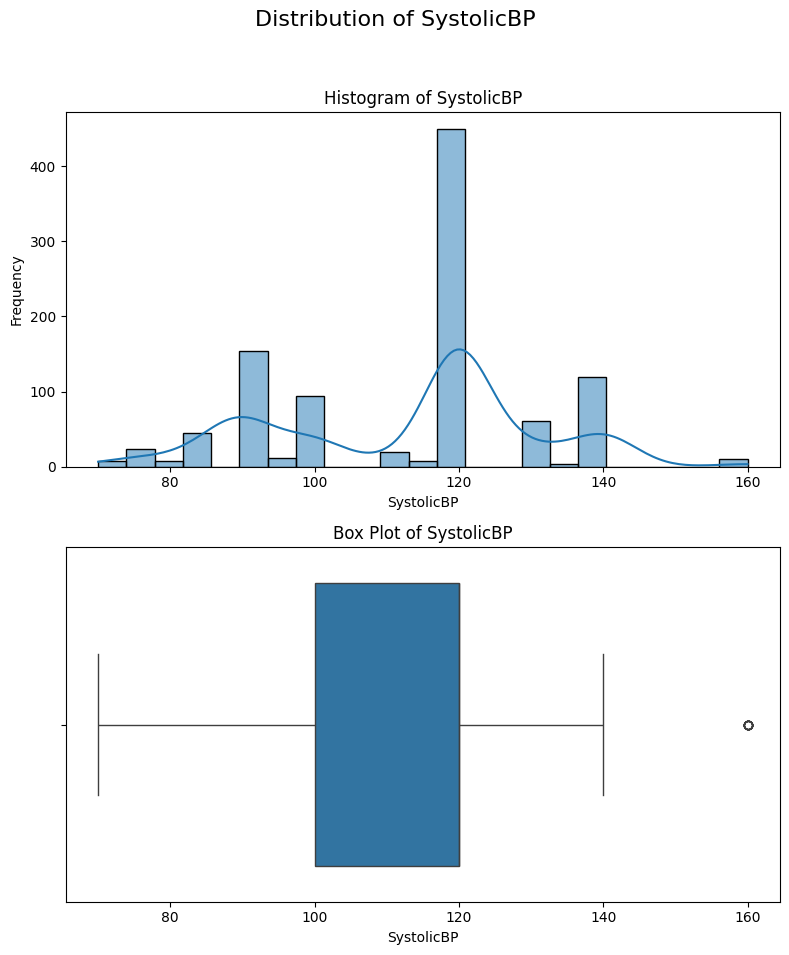

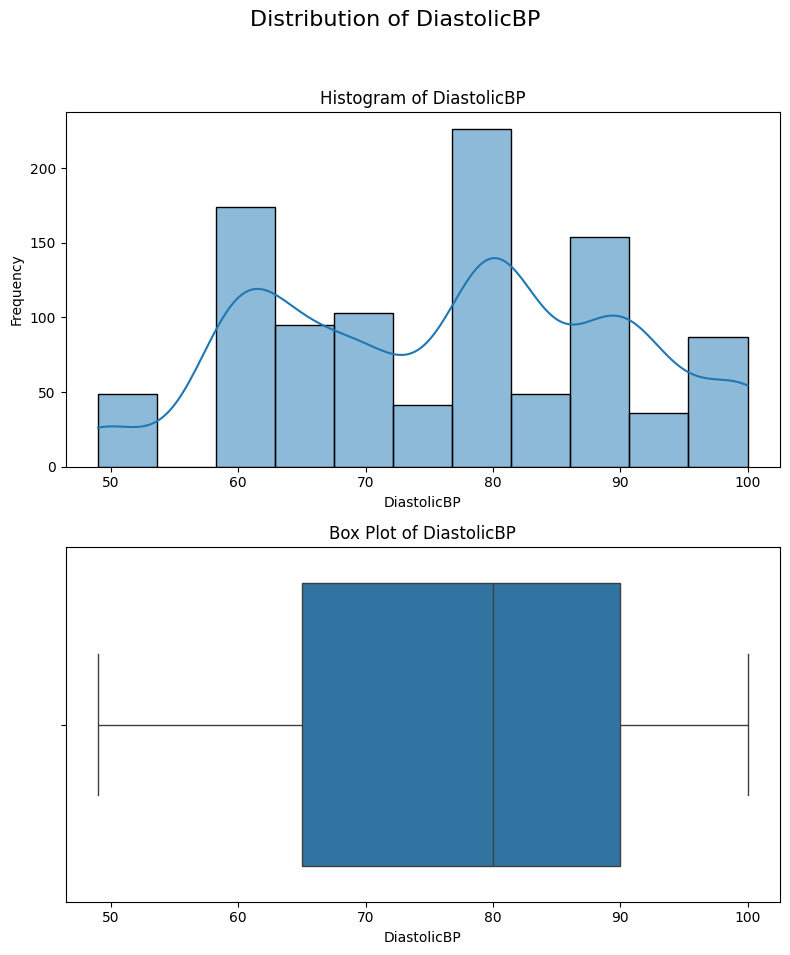

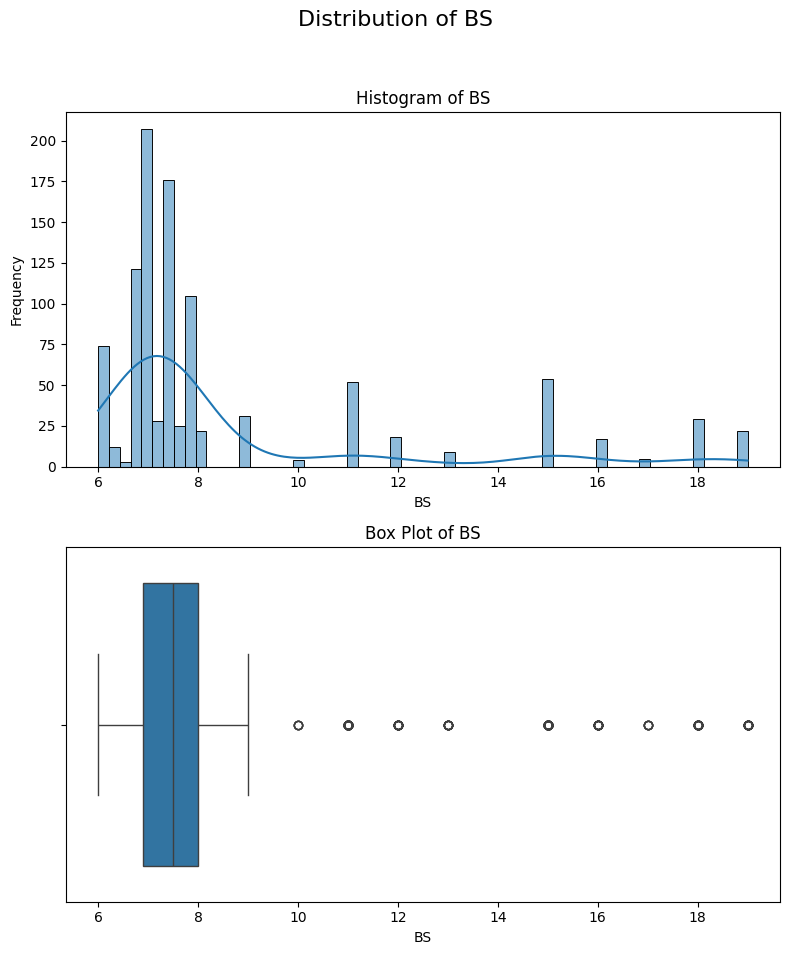

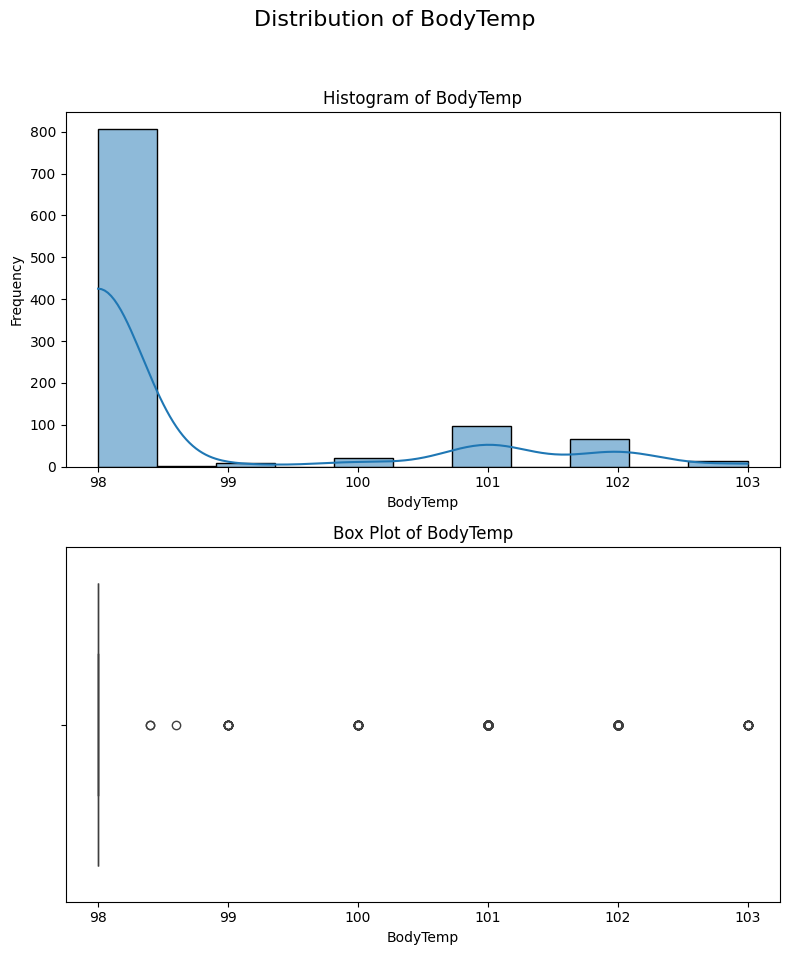

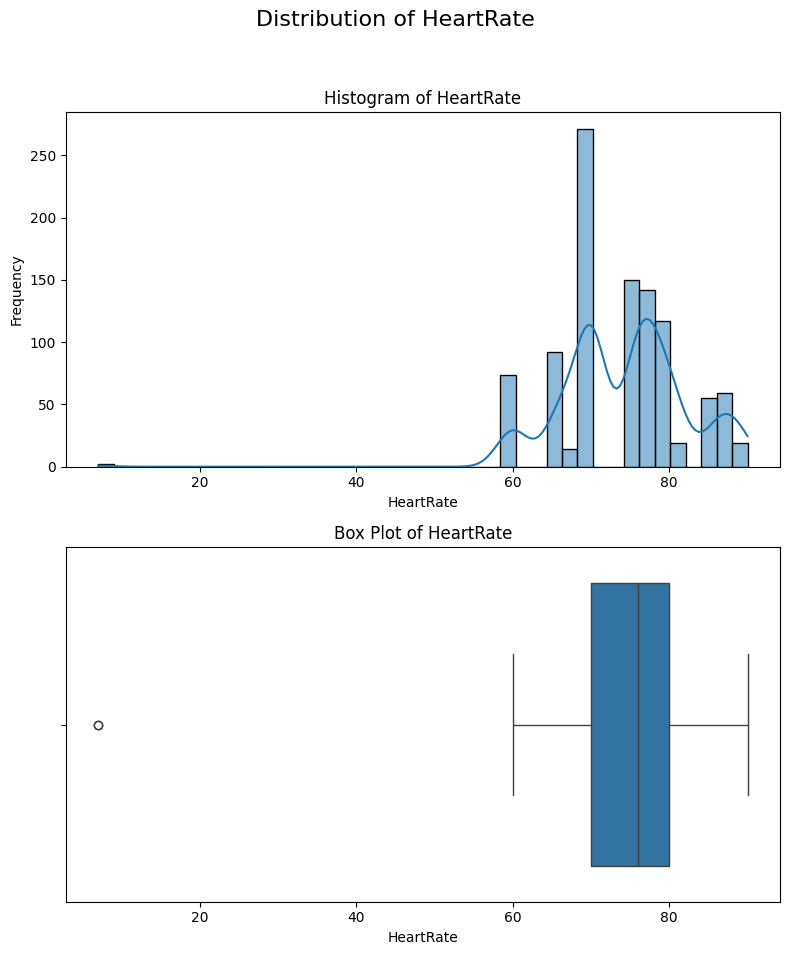

In [13]:
# List of numerical columns
numerical_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

# Iterate through each numerical column and create plots
for col in numerical_cols:
    fig, axes = plt.subplots(2, 1, figsize=(8, 10))
    fig.suptitle(f'Distribution of {col}', fontsize=16)

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Box plot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Box Plot of {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

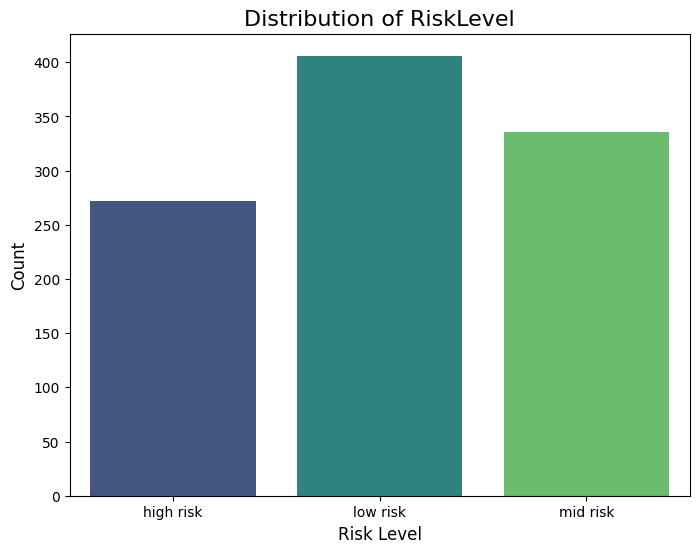

In [15]:
# Plotting the distribution of 'RiskLevel'
plt.figure(figsize=(8, 6))
sns.countplot(x='RiskLevel', data=df, palette='viridis', hue='RiskLevel', legend=False)
plt.title('Distribution of RiskLevel', fontsize=16)
plt.xlabel('Risk Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [6]:
X = data.drop('RiskLevel',axis=1)
y = data['RiskLevel']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,
                                               random_state=42)

In [7]:
ss = StandardScaler()

X_train = ss.fit_transform(X_train)

X_test= ss.transform(X_test)

In [8]:
#Applying XGBoost
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# Encode target labels to numerical values
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

#Create XGBClassifier
xgb_clf = xgb.XGBClassifier(n_estimators=50, max_depth=3,
                            learning_rate=0.05, gamma = 0.1,
                            subsample=0.8, colsample_bytree=0.8,
                            reg_alpha=0.1, reg_lambda=0.1,
                            random_state=42,
                            eval_metric='mlogloss')

xgb_clf = xgb_clf.fit(X_train, y_train_encoded)
print("Train accuracy:",xgb_clf.score(X_train,y_train_encoded))
print("Test accuracy:",xgb_clf.score(X_test,y_test_encoded))

y_pred_encoded = xgb_clf.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded) # Convert predictions back to original labels
print(y_pred)
cm = confusion_matrix(y_test_encoded, y_pred_encoded)
print(f'CM:',cm)
print(f'Accuracy:',accuracy_score(y_test_encoded, y_pred_encoded)* 100 ,'%')
print(classification_report(y_test_encoded, xgb_clf.predict(X_test), target_names=le.classes_))

Train accuracy: 0.7879746835443038
Test accuracy: 0.7205882352941176
['high risk' 'low risk' 'mid risk' 'low risk' 'high risk' 'low risk'
 'high risk' 'high risk' 'low risk' 'low risk' 'high risk' 'high risk'
 'low risk' 'low risk' 'low risk' 'low risk' 'low risk' 'low risk'
 'low risk' 'low risk' 'low risk' 'low risk' 'low risk' 'high risk'
 'high risk' 'low risk' 'low risk' 'low risk' 'mid risk' 'low risk'
 'low risk' 'low risk' 'low risk' 'high risk' 'low risk' 'low risk'
 'low risk' 'low risk' 'high risk' 'low risk' 'low risk' 'low risk'
 'low risk' 'mid risk' 'low risk' 'high risk' 'mid risk' 'low risk'
 'low risk' 'low risk' 'low risk' 'low risk' 'low risk' 'low risk'
 'low risk' 'low risk' 'low risk' 'low risk' 'low risk' 'low risk'
 'low risk' 'high risk' 'low risk' 'mid risk' 'low risk' 'low risk'
 'low risk' 'low risk' 'low risk' 'mid risk' 'high risk' 'low risk'
 'low risk' 'mid risk' 'high risk' 'low risk' 'low risk' 'low risk'
 'low risk' 'high risk' 'high risk' 'low risk'

In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import recall_score, classification_report, make_scorer

# --- 1. Load Data and Preparation ---
# Make sure "Maternal Health Risk Data Set.csv" is in the working directory
df = pd.read_csv("Maternal Health Risk Data Set.csv")

X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

# Stratified split to ensure risk levels are balanced in training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2. Label Encoding and Class Weighting (XGBoost requires sample_weight) ---

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Encoding Map: {'high risk': 0, 'low risk': 1, 'mid risk': 2}
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

# Aggressive Class Weights (High Risk gets 10x penalty for a False Negative)
original_class_weights = {
    'high risk': 10.0, # Most Critical
    'mid risk': 3.0,
    'low risk': 1.0     # Least Critical
}

# XGBoost uses the 'sample_weight' parameter, which must be calculated for each sample
# Map the weights onto the training target variable (y_train is still the original string Series)
sample_weights_train = y_train.map(original_class_weights)
print(f"Aggressive Weights Used: {original_class_weights} (applied via sample_weight)")

# --- 3. Define Custom Scorer for High Risk Recall ---

# The goal is to maximize RECALL for the most critical class: 'high risk' (Encoded as 0)
def recall_high_risk_scorer(y_true, y_pred, high_risk_label=0):
    # Calculate recall only for the specified label (0 = 'high risk')
    return recall_score(y_true, y_pred, labels=[high_risk_label], average='macro')

custom_scorer = make_scorer(recall_high_risk_scorer)

# --- 4. Define Model and Parameter Grid ---

# Initialize the classifier. Note: sample_weight is passed in the GridSearchCV.fit()
xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    # Use objective='multi:softmax' for multi-class prediction
    objective='multi:softmax'
)

# Define XGBoost-specific hyperparameters to search through
param_grid = {
    'n_estimators': [50, 100],        # Number of boosting rounds
    'max_depth': [3, 5],              # Max depth of the trees (controls complexity/overfitting)
    'learning_rate': [0.1, 0.05],     # Shrinkage (controls overfitting)
    'lambda': [0.1, 1.0]              # L2 regularization (to improve test accuracy/reduce overfitting)
}

# --- 5. Execute GridSearchCV ---

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring=custom_scorer,
    cv=3, # Using 3-fold cross-validation
    verbose=1,
    n_jobs=-1
)

# Crucial step: Pass the sample_weight to the GridSearchCV fit method
print("\nFitting GridSearchCV (This will take time)...")
grid_search.fit(X_train, y_train_encoded, sample_weight=sample_weights_train)


# --- 6. Report Best Model and Final Evaluation ---

print("\n" + "="*50)
print("             XGBOOST GRID SEARCH RESULTS")
print("="*50)
print(f"Optimal Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Recall (High Risk): {grid_search.best_score_:.4f}")

# Get the best model
best_xgb_clf = grid_search.best_estimator_

# Evaluate on the unseen test set
y_pred_test = best_xgb_clf.predict(X_test)

print("\n" + "="*50)
print("   FINAL CLASSIFICATION REPORT (BEST MODEL ON TEST SET)")
print("   Optimized for High Risk Recall")
print("="*50)
print(classification_report(y_test_encoded, y_pred_test, target_names=le.classes_))

Aggressive Weights Used: {'high risk': 10.0, 'mid risk': 3.0, 'low risk': 1.0} (applied via sample_weight)

Fitting GridSearchCV (This will take time)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

             XGBOOST GRID SEARCH RESULTS
Optimal Parameters Found: {'lambda': 0.1, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Best Cross-Validation Recall (High Risk): 0.9401

   FINAL CLASSIFICATION REPORT (BEST MODEL ON TEST SET)
   Optimized for High Risk Recall
              precision    recall  f1-score   support

   high risk       0.74      0.95      0.83        55
    low risk       0.84      0.40      0.54        81
    mid risk       0.56      0.79      0.65        67

    accuracy                           0.67       203
   macro avg       0.71      0.71      0.67       203
weighted avg       0.72      0.67      0.66       203



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:51:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV # CHANGED TO RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import recall_score, classification_report, make_scorer

# --- 1. Load Data and Preparation ---
df = pd.read_csv("Maternal Health Risk Data Set.csv")
X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2. Label Encoding and Class Weighting ---
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

original_class_weights = {
    'high risk': 5.0, 'mid risk': 3.0, 'low risk': 1.0
}
sample_weights_train = y_train.map(original_class_weights)
print(f"Aggressive Weights Used: {original_class_weights} (applied via sample_weight)")

# --- 3. Define Custom Scorer ---
def recall_high_risk_scorer(y_true, y_pred, high_risk_label=0):
    return recall_score(y_true, y_pred, labels=[high_risk_label], average='macro')
custom_scorer = make_scorer(recall_high_risk_scorer)

# --- 4. Define Model and Parameter Grid ---

# Set n_jobs = -1 here for maximum parallelization during fit.
# Remove it from the parameter grid.
xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    objective='multi:softmax',
    n_jobs=-1  # Set parallel processing here
)

# Reduced and refined grid for efficiency (n_jobs removed)
param_grid = {
    'n_estimators': [50, 100, 150, 200, 250, 300],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.20, 0.15, 0.1, 0.05],
    'lambda': [0.1, 1.0],
    'alpha': [0.1, 1.0],
    'gamma' : [0.1, 0.2, 0.3, 0.4, 0.5]
}

# --- 5. Execute RandomizedSearchCV ---

# Set n_iter to control the number of random combinations to test.
# 100 is a good starting point for exploring this large space.
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid, # CHANGED from param_grid to param_distributions
    n_iter=100,                     # Test 100 random combinations
    scoring=custom_scorer,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the grid search on the training data
print("\nFitting RandomizedSearchCV (Testing 100 combinations with 5-fold CV)...")
random_search.fit(X_train, y_train_encoded, sample_weight=sample_weights_train)


# --- 6. Report Best Model and Final Evaluation ---

print("\n" + "="*50)
print("       XGBOOST RANDOMIZED SEARCH RESULTS")
print("="*50)
print(f"Optimal Parameters Found: {random_search.best_params_}")
print(f"Best Cross-Validation Recall (High Risk): {random_search.best_score_:.4f}")

# Get the best model
best_xgb_clf = random_search.best_estimator_

# Evaluate on the unseen test set
y_pred_test = best_xgb_clf.predict(X_test)

print("\n" + "="*50)
print("   FINAL CLASSIFICATION REPORT (BEST MODEL ON TEST SET)")
print("   Optimized for High Risk Recall")
print("="*50)
print(classification_report(y_test_encoded, y_pred_test, target_names=le.classes_))

print("\n--- Additional Information ---")
print(f"Test Accuracy: {best_xgb_clf.score(X_test, y_test_encoded) * 100:.2f} %")
print(f"Confusion Matrix:\n{confusion_matrix(y_test_encoded, y_pred_test)}")

Aggressive Weights Used: {'high risk': 5.0, 'mid risk': 3.0, 'low risk': 1.0} (applied via sample_weight)

Fitting RandomizedSearchCV (Testing 100 combinations with 5-fold CV)...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

       XGBOOST RANDOMIZED SEARCH RESULTS
Optimal Parameters Found: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.2, 'lambda': 0.1, 'gamma': 0.2, 'alpha': 1.0}
Best Cross-Validation Recall (High Risk): 0.8800

   FINAL CLASSIFICATION REPORT (BEST MODEL ON TEST SET)
   Optimized for High Risk Recall
              precision    recall  f1-score   support

   high risk       0.91      0.91      0.91        55
    low risk       0.89      0.59      0.71        81
    mid risk       0.64      0.90      0.75        67

    accuracy                           0.78       203
   macro avg       0.81      0.80      0.79       203
weighted avg       0.81      0.78      0.78       203


--- Additional Information ---
Test Accuracy: 77.83 %
Confusion M

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:52:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [11]:
# Assuming you have the best model saved as 'final_xgb_clf'
y_prob = best_xgb_clf.predict_proba(X_test)
# y_prob[:, 0] holds the probabilities for 'high risk' (Class 0)

In [12]:
import numpy as np
from sklearn.metrics import recall_score, precision_score

# Assuming X_test, y_test_encoded, and final_xgb_clf are available
# Replace final_xgb_clf with your saved model object

# 1. Get predicted probabilities
y_prob = best_xgb_clf.predict_proba(X_test)
high_risk_prob = y_prob[:, 0] # Probabilities for Class 0 ('high risk')

results = []
# Iterate through thresholds from 0.4 down to 0.1
thresholds = np.arange(0.40, 0.09, -0.01)

for threshold in thresholds:
    # 2. Reclassify predictions based on the new threshold
    # If P(High Risk) >= threshold, predict High Risk (0), otherwise predict the model's original class.

    # Start with the original predictions
    y_pred_new = best_xgb_clf.predict(X_test)

    # Overwrite predictions where High Risk probability meets the threshold
    y_pred_new[high_risk_prob >= threshold] = 0

    # 3. Calculate key metrics for the High Risk class (Class 0)
    recall = recall_score(y_test_encoded, y_pred_new, labels=[0], average='macro')
    precision = precision_score(y_test_encoded, y_pred_new, labels=[0], average='macro', zero_division=0)

    results.append({
        'Threshold': round(threshold, 2),
        'High_Risk_Recall': recall,
        'High_Risk_Precision': precision,
        'False_Negatives': int(55 * (1 - recall)) # 55 is the actual support for High Risk
    })

# Convert results to DataFrame for easy analysis
results_df = pd.DataFrame(results)

print("\n--- Threshold Optimization Results ---")
display(results_df[results_df['High_Risk_Recall'] >= 0.98].head(5))

# The lowest threshold that achieves a Recall of 1.0 (or very close) is your final safety setting.


--- Threshold Optimization Results ---


,Threshold,High_Risk_Recall,High_Risk_Precision,False_Negatives
20,0.20,0.981818,0.760563,1
21,0.19,0.981818,0.760563,1
22,0.18,0.981818,0.760563,1
23,0.17,0.981818,0.750000,1
24,0.16,0.981818,0.739726,1
